# Model Comparison

## Objective
This notebook compares the main candidate models on the validation cohort and summarizes which approach should move forward to final testing.

## Validation Protocol

All models are evaluated on the same temporal validation cohort (2012).

- Train: ≤ 2011  
- Validation: 2012  
- Test: 2013–2014 (held out)

Only the validation cohort is used in this notebook for model comparison.

The test set is not used here to avoid leakage and ensure a fair final evaluation.

## Why PR-AUC?

Default and prepayment are rare-event outcomes, so PR-AUC is the main comparison metric.

PR-AUC is more informative than accuracy or ROC-AUC because it focuses on ranking the positive class under strong class imbalance.

## Validation Results

All models were evaluated on the same validation cohort (`cohort_year = 2012`).

The main metric is PR-AUC because both default and prepayment are rare-event problems.

| Model | Default PR-AUC | Prepay PR-AUC |
|---|---:|---:|
| Binary Default NN | 0.0045 | — |
| Binary Prepay NN | — | 0.0095 |
| Logistic Regression | 0.0081 | 0.0123 |
| NCR (3-class) | 0.0177 | 0.0151 |
| LightGBM (3-class) | 0.0178 | 0.0182 |

In [2]:
import pandas as pd
import numpy as np

In [3]:
results = pd.DataFrame([
    {"model": "Binary Default NN", "pr_auc_default": 0.0045, "pr_auc_prepay": np.nan},
    {"model": "Binary Prepay NN", "pr_auc_default": np.nan, "pr_auc_prepay": 0.0095},
    {"model": "Logistic Regression", "pr_auc_default": 0.0081, "pr_auc_prepay": 0.0123},
    {"model": "NCR", "pr_auc_default": 0.0177, "pr_auc_prepay": 0.0151},
    {"model": "LightGBM", "pr_auc_default": 0.0178, "pr_auc_prepay": 0.0182},
])

results

,model,pr_auc_default,pr_auc_prepay
0,Binary Default NN,0.0045,NaN
1,Binary Prepay NN,NaN,0.0095
2,Logistic Regression,0.0081,0.0123
3,NCR,0.0177,0.0151
4,LightGBM,0.0178,0.0182


## Interpretation

Key takeaways:

- Binary formulations are weak
- Logistic Regression provides a useful linear baseline
- NCR is competitive for default prediction
- LightGBM performs best overall, especially for prepayment prediction

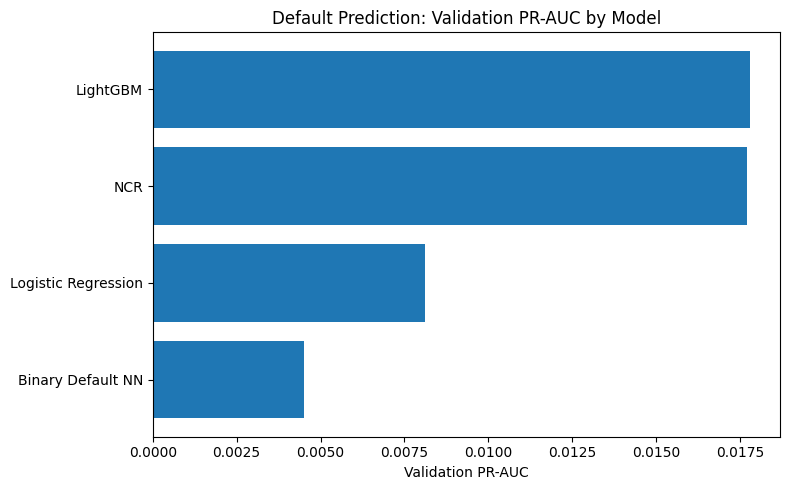

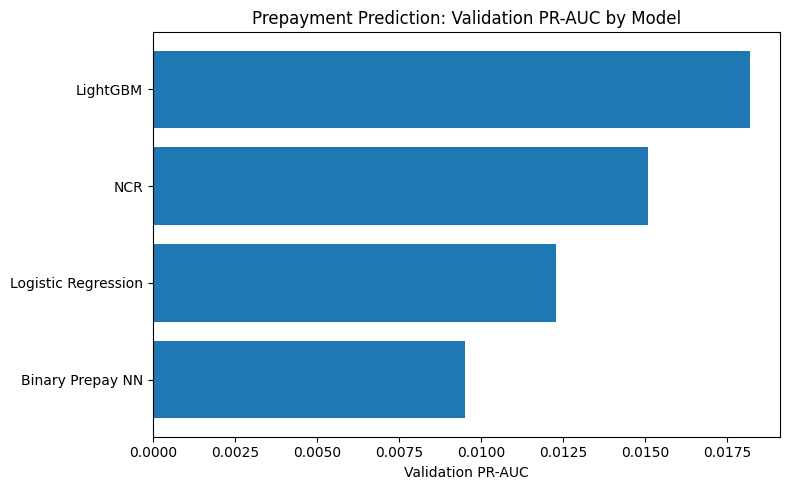

In [4]:
import matplotlib.pyplot as plt

plot_df = results.copy()

# Default PR-AUC plot
default_df = plot_df.dropna(subset=["pr_auc_default"]).sort_values("pr_auc_default", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(default_df["model"], default_df["pr_auc_default"])
plt.xlabel("Validation PR-AUC")
plt.title("Default Prediction: Validation PR-AUC by Model")
plt.tight_layout()
plt.show()

# Prepay PR-AUC plot
prepay_df = plot_df.dropna(subset=["pr_auc_prepay"]).sort_values("pr_auc_prepay", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(prepay_df["model"], prepay_df["pr_auc_prepay"])
plt.xlabel("Validation PR-AUC")
plt.title("Prepayment Prediction: Validation PR-AUC by Model")
plt.tight_layout()
plt.show()

### Interpretation

The bar plots show a clear ranking.

For default prediction, the NCR model and LightGBM are very close, with LightGBM only slightly ahead.

For prepayment prediction, LightGBM has a clearer advantage. This suggests that the tabular tree-based model captures nonlinear interactions more effectively in the current feature set.

In [5]:
summary_rows = []

best_default = results["pr_auc_default"].max(skipna=True)
best_prepay = results["pr_auc_prepay"].max(skipna=True)

for _, row in results.iterrows():
    summary_rows.append({
        "model": row["model"],
        "default_pct_of_best": (
            row["pr_auc_default"] / best_default if pd.notna(row["pr_auc_default"]) else np.nan
        ),
        "prepay_pct_of_best": (
            row["pr_auc_prepay"] / best_prepay if pd.notna(row["pr_auc_prepay"]) else np.nan
        ),
    })

relative_df = pd.DataFrame(summary_rows)
relative_df

,model,default_pct_of_best,prepay_pct_of_best
0,Binary Default NN,0.252809,NaN
1,Binary Prepay NN,NaN,0.521978
2,Logistic Regression,0.455056,0.675824
3,NCR,0.994382,0.829670
4,LightGBM,1.000000,1.000000


## Combined Summary Table

The table below combines absolute PR-AUC values with relative performance against the best validation result for each task.

This gives a compact summary of both overall quality and closeness to the strongest model.

In [6]:
final_summary = results.merge(relative_df, on="model")
final_summary["pr_auc_default"] = final_summary["pr_auc_default"].round(4)
final_summary["pr_auc_prepay"] = final_summary["pr_auc_prepay"].round(4)
final_summary["default_pct_of_best"] = final_summary["default_pct_of_best"].round(3)
final_summary["prepay_pct_of_best"] = final_summary["prepay_pct_of_best"].round(3)

final_summary

,model,pr_auc_default,pr_auc_prepay,default_pct_of_best,prepay_pct_of_best
0,Binary Default NN,0.0045,NaN,0.253,NaN
1,Binary Prepay NN,NaN,0.0095,NaN,0.522
2,Logistic Regression,0.0081,0.0123,0.455,0.676
3,NCR,0.0177,0.0151,0.994,0.830
4,LightGBM,0.0178,0.0182,1.000,1.000


This table reinforces the main pattern:

- Binary models are weak diagnostic baselines
- Logistic Regression is useful as a linear reference point
- NCR is competitive for default prediction
- LightGBM is strongest overall, especially for prepayment

## Lift Analysis

### Why Lift?

PR-AUC measures overall ranking quality, but it does not directly show how many true events are concentrated in the highest-risk segment.

Lift-style capture metrics answer a more practical question:

> If we focus on the riskiest loans first, how many real events do we catch?

This is especially useful for portfolio and cash-flow applications.


In [ ]:
lift_summary = pd.DataFrame([
    {"model": "NCR", "event": "Default", "top_5_capture": 0.05429864253393665, "top_10_capture": 0.10105580693815988},
    {"model": "LightGBM", "event": "Default", "top_5_capture": 0.22322775263951736, "top_10_capture": 0.39441930618401205},
    {"model": "NCR", "event": "Prepay", "top_5_capture": 0.05324400564174894, "top_10_capture": 0.1071932299012694},
    {"model": "LightGBM", "event": "Prepay", "top_5_capture": 0.09943582510578279, "top_10_capture": 0.16502115655853314},
])

lift_summary

,model,event,top_5_capture,top_10_capture
0,NCR,Default,0.054299,0.101056
1,LightGBM,Default,0.223228,0.394419
2,NCR,Prepay,0.053244,0.107193
3,LightGBM,Prepay,0.099436,0.165021


The lift table shows that LightGBM substantially outperforms NCR in top-segment capture, especially for default prediction.

This means that even when PR-AUC values are fairly close, the models can differ a lot in how effectively they prioritize the riskiest loans.

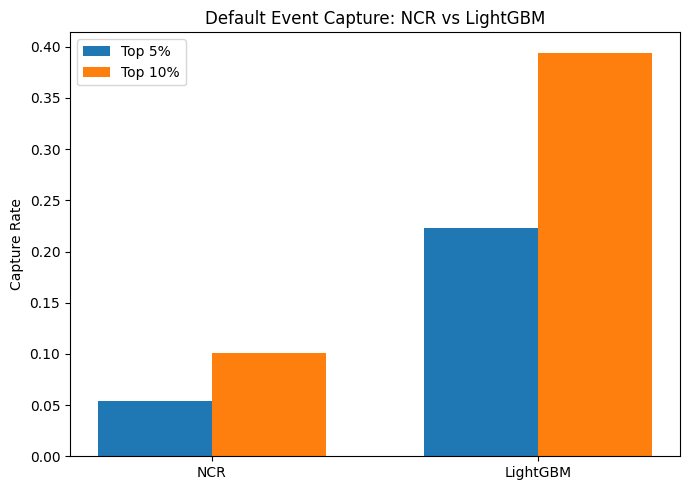

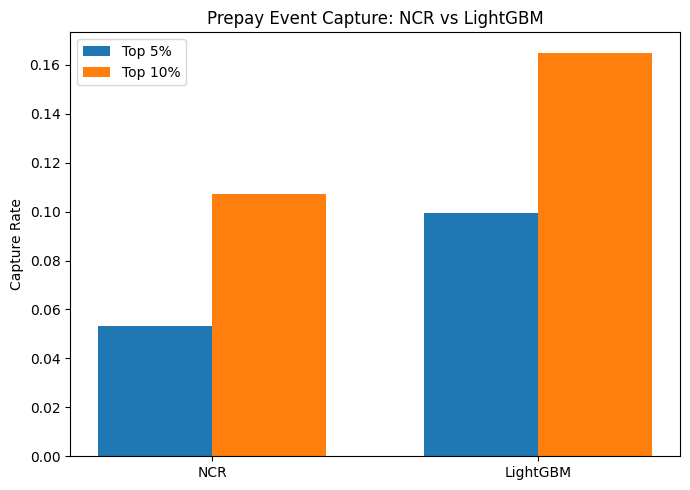

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

default_lift = lift_summary[lift_summary["event"] == "Default"]
prepay_lift = lift_summary[lift_summary["event"] == "Prepay"]

# Default
x = np.arange(len(default_lift["model"]))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, default_lift["top_5_capture"], width, label="Top 5%")
plt.bar(x + width/2, default_lift["top_10_capture"], width, label="Top 10%")
plt.xticks(x, default_lift["model"])
plt.ylabel("Capture Rate")
plt.title("Default Event Capture: NCR vs LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

# Prepay
x = np.arange(len(prepay_lift["model"]))

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, prepay_lift["top_5_capture"], width, label="Top 5%")
plt.bar(x + width/2, prepay_lift["top_10_capture"], width, label="Top 10%")
plt.xticks(x, prepay_lift["model"])
plt.ylabel("Capture Rate")
plt.title("Prepay Event Capture: NCR vs LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Lift analysis evaluates ranking quality rather than average classification performance.

LightGBM strongly outperforms NCR in concentrating true default events among the highest-risk observations. The difference is especially large for default prediction, where the top 10% of LightGBM-ranked loan-months capture about 39% of defaults, compared with about 10% for NCR.

The lift table shows that LightGBM substantially outperforms NCR in top-segment capture, especially for default prediction.

This means that even when PR-AUC values are fairly close, the models can differ a lot in how effectively they prioritize the riskiest loans.